<a href="https://colab.research.google.com/github/Adithyasajeev22/Deep-Learning/blob/main/CNN(NUERAL_NETWORK)_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CONVOLUTIONAL NEURAL NETWORKS (CNNs)**

In [ ]:
import  numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from itertools import product


In [ ]:
# set the param
plt.rc('figure', autolayout=True)
plt.rc('image', cmap='magma')

In [ ]:
# define the kernel
kernel = tf.constant([[-1, -1, -1],
                    [-1,  8, -1],
                    [-1, -1, -1],
                   ])

In [ ]:
# load the image
image = tf.io.read_file("/content/pexels-wj-y-2160483207-37274677.jpg")
image = tf.io.decode_jpeg(image, channels=1)
image = tf.image.resize(image, size=[300, 300])


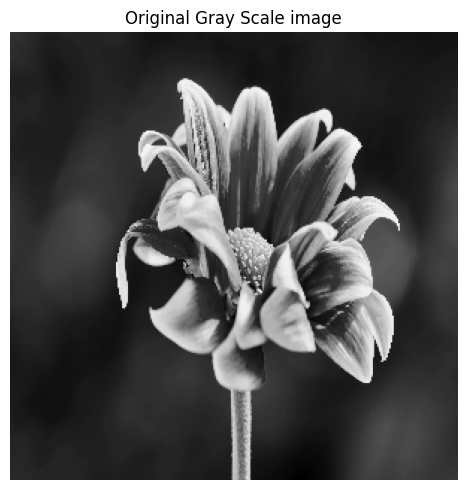

In [ ]:
# plot the image
img = tf.squeeze(image).numpy()
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original Gray Scale image')
plt.show();

In [ ]:
# Reformat
image = tf.image.convert_image_dtype(image, dtype=tf.float32)
image = tf.expand_dims(image, axis=0)
kernel = tf.reshape(kernel, [*kernel.shape, 1, 1])
kernel = tf.cast(kernel, dtype=tf.float32)

In [ ]:
# convolution layer
conv_fn = tf.nn.conv2d

image_filter = conv_fn(
    input=image,
    filters=kernel,
    strides=1, # or (1, 1)
    padding='SAME',
)

plt.figure(figsize=(15, 5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

Text(0.5, 1.0, 'Convolution')

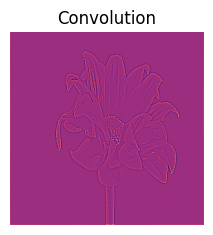

In [ ]:
# Plot the convolved image
plt.subplot(1, 3, 1)

plt.imshow(
    tf.squeeze(image_filter)
)
plt.axis('off')
plt.title('Convolution')

In [ ]:
# activation layer
relu_fn = tf.nn.relu

In [ ]:
# Image detection
image_detect = relu_fn(image_filter)

Text(0.5, 1.0, 'Activation')

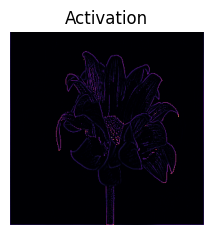

In [ ]:
plt.subplot(1, 3, 2)
plt.imshow(
    # Reformat for plotting
    tf.squeeze(image_detect)
)

plt.axis('off')
plt.title('Activation')

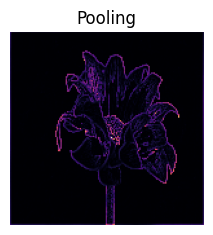

In [ ]:
# Pooling layer
pool = tf.nn.pool
image_condense = pool(input=image_detect,
                             window_shape=(2, 2),
                             pooling_type='MAX',
                             strides=(2, 2),
                             padding='SAME',
                            )

plt.subplot(1, 3, 3)
plt.imshow(tf.squeeze(image_condense))
plt.axis('off')
plt.title('Pooling')
plt.show()

# CNN BASICS

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt


In [ ]:
(x_train,y_train),(x_test,y_test)=datasets.cifar10.load_data()

If a pixel was 0 → 0 / 255 = 0

If a pixel was 255 → 255 / 255 = 1

If a pixel was 128 → 128 / 255 ≈ 0.50

In [ ]:
x_train,x_test=x_train/255,x_test/255 #normal pixel values to between 0 and 1



1.   .Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3))






  *   Conv2D creates a convolutional layer.
  *   32 means it will learn 32 filters (feature maps).


  *   32 means it will learn 32 filters (feature maps).
  *   (3,3) is the size of each filter (kernel) — a 3×3 grid.



  *   activation="relu" applies the ReLU activation function to introduce non-linearity.


2.   input_shape=(32,32,3) sets the input image dimensions:


*   32×32
*   3 channels (RGB image)







In [ ]:
model=models.Sequential([ # built cnn models
    layers.Conv2D(32,(3,3),activation="relu",input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation="relu"),

    layers.Flatten(),
    layers.Dense(64,activation="relu"),
    layers.Dense(10,activation="softmax")
])

In [ ]:
model.compile(optimizer="adam", # compile model
              loss="sparse_categorical_crossentropy",
              metrics=['accuracy'])

In [ ]:
history=model.fit(x_train,y_train,epochs=20, #train the model
                  validation_data=(x_test,y_test))

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 42ms/step - accuracy: 0.4425 - loss: 1.5288 - val_accuracy: 0.5291 - val_loss: 1.2955
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.5874 - loss: 1.1684 - val_accuracy: 0.6222 - val_loss: 1.0658
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.6430 - loss: 1.0178 - val_accuracy: 0.6434 - val_loss: 1.0136
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 43ms/step - accuracy: 0.6744 - loss: 0.9257 - val_accuracy: 0.6401 - val_loss: 1.0270
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 52ms/step - accuracy: 0.6985 - loss: 0.8561 - val_accuracy: 0.6822 - val_loss: 0.9147
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.7213 - loss: 0.7956 - val_accuracy: 0.6934 - val_loss: 0.8964
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 41ms/step - accuracy: 0.7359 - loss: 0.7506 - val_accuracy: 0.6937 - val_loss: 0.9136
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.7515 -

In [ ]:
test_loss,test_acc=model.evaluate(x_test,y_test) #evaluate the model
print(f"Test accuracy:{test_acc:.6f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6966 - loss: 1.1810
Test accuracy:0.696600


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 41ms/step - accuracy: 0.4383 - loss: 1.5371 - val_accuracy: 0.5459 - val_loss: 1.2730
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.5840 - loss: 1.1675 - val_accuracy: 0.6271 - val_loss: 1.0702
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.6370 - loss: 1.0294 - val_accuracy: 0.6434 - val_loss: 0.9939
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 42ms/step - accuracy: 0.6727 - loss: 0.9273 - val_accuracy: 0.6641 - val_loss: 0.9617
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 41ms/step - accuracy: 0.6984 - loss: 0.8623 - val_accuracy: 0.6655 - val_loss: 0.9343
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.7183 - loss: 0.8062 - val_accuracy: 0.6905 - val_loss: 0.8969
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 43ms/step - accuracy: 0.7319 - loss: 0.7574 - val_accuracy: 0.6861 - val_loss: 0.9262
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - accuracy: 0.7473 -

/tmp/ipykernel_59426/4217052868.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = class_names[int(y_test[index])]


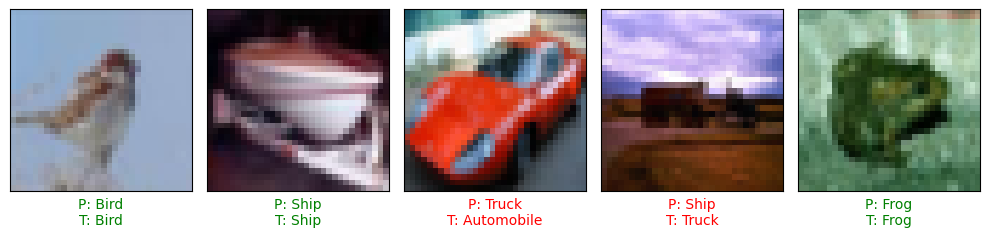

In [ ]:
# 1. Load and Preprocess the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Class names for CIFAR-10
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# 2. Build the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 3. Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train the model
history = model.fit(x_train, y_train, epochs=20,
                    validation_data=(x_test, y_test))

# 5. Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nTest accuracy: {test_acc:.4f}")

# 6. Predict on test images
predictions = model.predict(x_test)

# 7. Display predictions for 5 random test images
num_images = 5
plt.figure(figsize=(10, 5))

for i in range(num_images):
    index = np.random.randint(0, len(x_test))
    plt.subplot(1, num_images, i + 1)
    plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.imshow(x_test[index])

    predicted_label = class_names[np.argmax(predictions[index])]
    true_label = class_names[int(y_test[index])]

    color = 'green' if predicted_label == true_label else 'red'
    plt.xlabel(f"P: {predicted_label}\nT: {true_label}", color=color)

plt.tight_layout()
plt.show()